In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "sojanprajapati/emg-signal-for-gesture-recognition")

print("Path to dataset files:", path)

100%|██████████| 16.4M/16.4M [00:01<00:00, 15.2MB/s]

Extracting files...


Path to dataset files: /home/carlos/.cache/kagglehub/datasets/sojanprajapati/emg-signal-for-gesture-recognition/versions/1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [36]:
df = pd.read_csv("data/EMG_data.csv", nrows=25000)
df = df.drop(columns=["label"], axis=1)
# 1: hand at rest, 2: hand clenched in a fist, 3: wrist flexion,
df["class"] = df["class"].apply(lambda x: x if x in [1, 2, 3] else np.nan)
df = df.dropna()
df["class"] = df["class"].astype(int)
df.head()

,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class
2287,2400,-0.00001,0.00000,-0.00001,0.00000,0.00000,-0.00001,-0.00001,0.00001,1
2288,2401,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1
2289,2402,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1
2290,2403,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1
2291,2404,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1


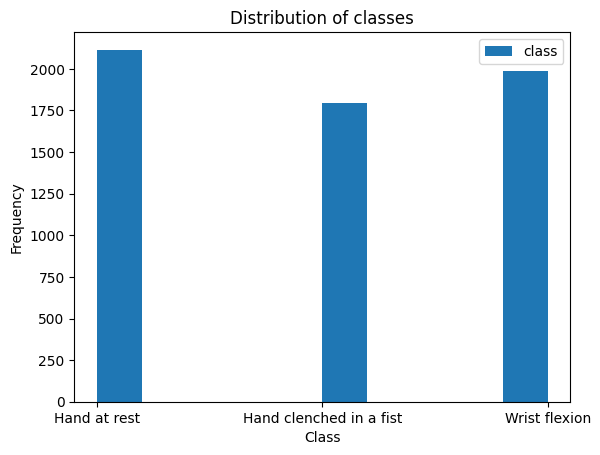

In [ ]:
df.plot(y="class", kind="hist")
plt.title("Distribution of classes")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.xticks([1, 2, 3], ["Hand at rest",
           "Hand clenched in a fist", "Wrist flexion"])
plt.show()

<Axes: >

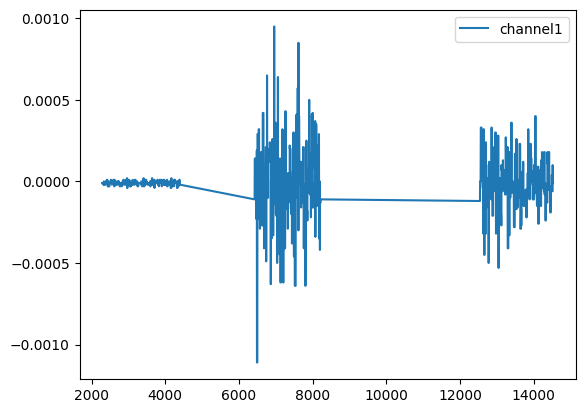

In [40]:
df.plot(y="channel1", kind="line")

In [54]:
def series_rms(s: pd.Series, window_size: int = 150) -> pd.Series:
    return s.pow(2).rolling(window=window_size, center=True).mean().apply(np.sqrt)

In [ ]:
SAMPLE_LENGTH = 150  # ms

df["rms_1"] = series_rms(df["channel1"], SAMPLE_LENGTH)

df.plot(y="rms_1")